# Model Training and Evaluation

This notebook trains a Random Forest classifier using
the selected 500 gene expression features.

The model predicts:

- Healthy
- Oral Cancer

In [11]:
import pandas as pd

df = pd.read_csv(
    "../dataset/final_selected_dataset.csv"
)

df.head()

,ILMN_1700461,ILMN_1776119,ILMN_1658083,ILMN_1738921,ILMN_2225595,ILMN_2352009,ILMN_1679600,ILMN_1691714,ILMN_1663132,ILMN_1700349,...,ILMN_1672940,ILMN_2078141,ILMN_1654612,ILMN_1698048,ILMN_2171640,ILMN_1670640,ILMN_2045175,ILMN_1800750,ILMN_2175447,Label
0,935.6070,234.3474,118.2800,893.8805,592.6266,374.2499,185.0592,163.18570,1589.801,103.54250,...,333.9715,458.4577,836.6818,201.1774,221.9025,111.72160,198.4151,712.3456,1163.6610,0
1,977.2614,145.9691,109.0556,644.9527,570.0883,507.2513,358.0979,198.91040,2594.574,134.12930,...,228.6719,377.9895,1905.3080,170.5912,173.0880,97.06413,188.7685,1317.0420,2195.4550,0
2,983.6641,257.5760,106.1608,712.3958,618.5681,395.5662,180.6711,64.65596,1119.165,74.19514,...,184.3754,272.9053,1132.6740,123.8508,152.4242,83.12721,193.6905,621.4002,1192.7820,0
3,1600.8570,307.8341,130.4562,1260.5380,797.9879,755.7017,328.9742,187.57900,3637.393,132.63230,...,310.4337,518.6738,1297.1330,175.4108,210.0579,121.11830,334.0703,2405.5520,1790.9140,0
4,1412.7820,400.2456,131.5690,755.1400,505.1268,655.3365,347.9955,191.31880,1811.977,73.71181,...,505.9775,296.5089,892.4323,126.5319,174.2380,83.72725,210.2115,1444.1460,989.1553,0


In [12]:
X = df.drop(
    "Label",
    axis=1
)

y = df["Label"]

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (80, 500)
Labels: (80,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 64
Testing Samples: 16


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = rf.predict(X_test)

y_pred[:10]

array([0, 1, 1, 1, 1, 0, 1, 0, 0, 0])

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

Accuracy: 81.25 %


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.78      0.88      0.82         8

    accuracy                           0.81        16
   macro avg       0.82      0.81      0.81        16
weighted avg       0.82      0.81      0.81        16



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[6, 2],
       [1, 7]])

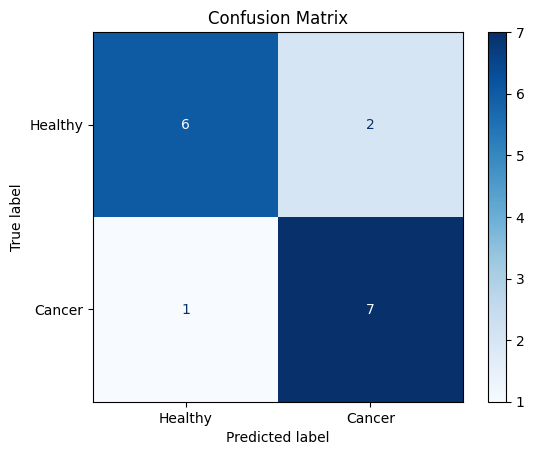

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Cancer"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [20]:
import joblib

joblib.dump(
    rf,
    "../backend/models/oral_cancer_rf.pkl"
)

print(
    "Model Saved"
)

Model Saved


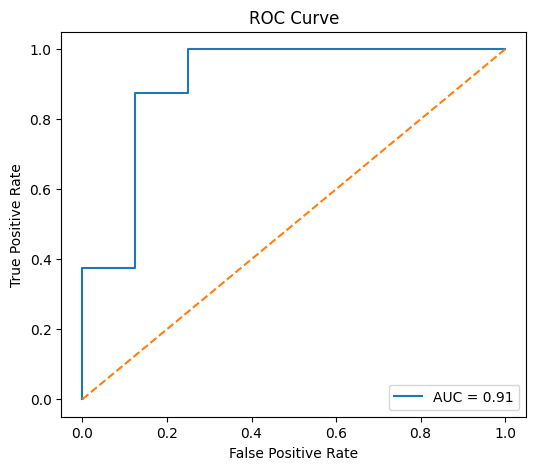

In [22]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

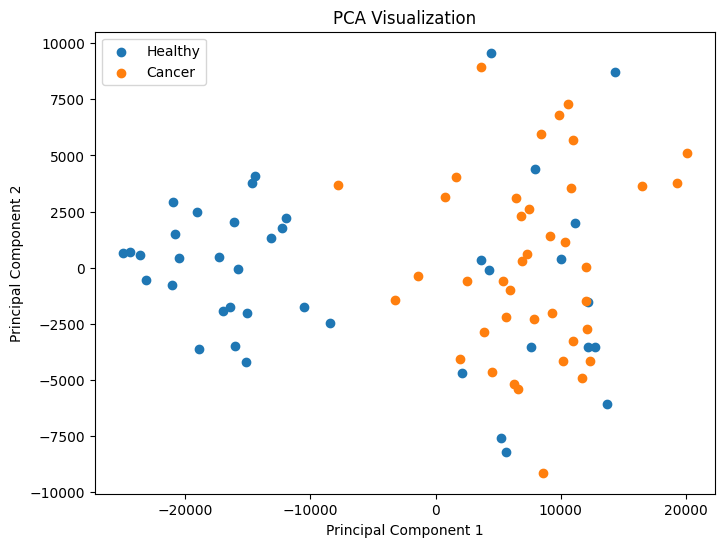

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="Healthy"
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="Cancer"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization"
)

plt.legend()

plt.show()

## Conclusion

Model Used:
Random Forest

Training Samples:
64

Testing Samples:
16

Accuracy:
81.25%

The model successfully learned gene-expression
patterns associated with oral cancer.